# 05 · Segmentation Model — EfficientNet-UNet v1

Baseline segmentation model được train trên pseudo-label từ notebook 04. Mục tiêu là xem liệu supervision yếu (weak supervision từ Grad-CAM) có đủ để train một UNet hoạt động được không — trước khi đầu tư vào các kỹ thuật phức tạp hơn ở notebook 07-09.

---

**Những gì notebook này làm:**

1. **Load pseudo-label dataset** — processed_train/ + pseudo_labels_train/ từ notebook 04
2. **Định nghĩa model** — EfficientNet-B0 encoder + UNet decoder, pretrained ImageNet
3. **Loss & metrics** — BCE + Dice loss, IoU/Dice/Precision/Recall trên từng batch
4. **Training loop** — early stopping (patience=7, max 30 epochs), Adam lr=1e-4
5. **Test evaluation** — đánh giá trên held-out test split
6. **Visualization** — training curves + sample predictions

**Output:** Checkpoint tại `models/segmentation/checkpoints/` · Metrics tại `models/segmentation/metrics/` · Figures tại `visualizations/segmentation_v1/`

In [ ]:
import os
import sys
import json
import random

proj_root = r'e:\Master\thesis-clean'
sys.path.insert(0, proj_root)
sys.path.insert(0, os.path.join(proj_root, 'utils'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import torchvision.transforms.functional as TF
from PIL import Image

from utils.models import EfficientNetUNet

plt.style.use('default')
sns.set_palette("husl")

CLASS_NAMES  = ["ALGAL_LEAF_SPOT", "ALLOCARIDARA_ATTACK", "HEALTHY_LEAF", "LEAF_BLIGHT", "PHOMOPSIS_LEAF_SPOT"]
CLASS_LABELS = ["Algal Leaf Spot", "Allocaridara Attack", "Healthy Leaf", "Leaf Blight", "Phomopsis Leaf Spot"]
CLASS_COLORS = ["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
IDX_TO_LABEL = {i: label for i, label in enumerate(CLASS_LABELS)}

VIZ_DIR = os.path.join(proj_root, "visualizations", "segmentation_v1")
os.makedirs(VIZ_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"proj_root: {proj_root}")

## Load Pseudo-Label Dataset

Dataset cho segmentation gồm 2 thư mục đồng bộ: ảnh gốc resize 224×224 (`processed_train/`) và binary mask tương ứng (`pseudo_labels_train/`). Cả hai đều được tạo từ notebook 04 — mỗi cặp (ảnh, mask) có cùng tên file với hậu tố `_pseudo.png` cho mask.

Split 70/15/15 từ pseudo-label dataset — không dùng lại split từ classification vì mục đích khác. Seed cố định 42 để reproducible giữa các lần chạy.

In [2]:
# Đường dẫn từ notebook 04
IMAGE_DIR = os.path.join(proj_root, 'notebooks', 'data', 'processed_train')
MASK_DIR  = os.path.join(proj_root, 'notebooks', 'data', 'pseudo_labels_train')

# Fallback nếu không tìm thấy
if not os.path.exists(IMAGE_DIR):
    IMAGE_DIR = 'data/processed_train'
if not os.path.exists(MASK_DIR):
    MASK_DIR = 'data/pseudo_labels_train'

print('IMAGE_DIR:', IMAGE_DIR, '| exists:', os.path.exists(IMAGE_DIR))
print('MASK_DIR:', MASK_DIR, '| exists:', os.path.exists(MASK_DIR))

if os.path.exists(IMAGE_DIR):
    imgs_sample = [f for f in os.listdir(IMAGE_DIR) if f.endswith(('.jpg', '.png'))][:5]
    print('Images (5 đầu):', imgs_sample)
if os.path.exists(MASK_DIR):
    masks_sample = [f for f in os.listdir(MASK_DIR) if f.endswith('_pseudo.png')][:5]
    print('Masks (5 đầu):', masks_sample)

IMAGE_DIR: e:\Master\thesis-clean\notebooks\data\processed_train | exists: True
MASK_DIR: e:\Master\thesis-clean\notebooks\data\pseudo_labels_train | exists: True
Images (5 đầu): ['ALGAL_LEAF_SPOT_to_label_1.jpg', 'ALGAL_LEAF_SPOT_to_label_10.jpg', 'ALGAL_LEAF_SPOT_to_label_101.jpg', 'ALGAL_LEAF_SPOT_to_label_102.jpg', 'ALGAL_LEAF_SPOT_to_label_103.jpg']
Masks (5 đầu): ['ALGAL_LEAF_SPOT_to_label_1.jpg_pseudo.png', 'ALGAL_LEAF_SPOT_to_label_10.jpg_pseudo.png', 'ALGAL_LEAF_SPOT_to_label_101.jpg_pseudo.png', 'ALGAL_LEAF_SPOT_to_label_102.jpg_pseudo.png', 'ALGAL_LEAF_SPOT_to_label_103.jpg_pseudo.png']


In [3]:
class DurianSegDataset(Dataset):
    def __init__(self, image_dir, mask_dir, image_size=224, augment=False):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.image_size = image_size
        self.augment   = augment

        self.samples = []
        for fname in os.listdir(mask_dir):
            if not fname.endswith('_pseudo.png'):
                continue
            # e.g. ALGAL_LEAF_SPOT_to_label_100.jpg_pseudo.png -> ALGAL_LEAF_SPOT_to_label_100.jpg
            img_name = fname.replace('_pseudo.png', '')
            img_path  = os.path.join(image_dir, img_name)
            mask_path = os.path.join(mask_dir, fname)
            if os.path.exists(img_path):
                self.samples.append((img_path, mask_path))

        print(f'[Dataset] Found {len(self.samples)} image-mask pairs')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]

        img  = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')

        img  = img.resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), Image.NEAREST)

        if self.augment:
            if random.random() > 0.5:
                img  = TF.hflip(img)
                mask = TF.hflip(mask)
            if random.random() > 0.5:
                img  = TF.vflip(img)
                mask = TF.vflip(mask)

        img  = TF.to_tensor(img)
        img  = TF.normalize(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()

        return {
            'image': img,
            'label': mask,
            'img_path': img_path,
        }


full_dataset = DurianSegDataset(IMAGE_DIR, MASK_DIR, augment=False)

n = len(full_dataset)
n_train = int(0.7 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

print(f'Split: train={n_train}, val={n_val}, test={n_test}')

# Fix seed để reproducible
generator = torch.Generator().manual_seed(42)
train_seg, val_seg, test_seg = random_split(full_dataset, [n_train, n_val, n_test], generator=generator)

# Bật augment cho train
train_seg.dataset.augment = True

train_loader = DataLoader(train_seg, batch_size=8, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_seg,   batch_size=8, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_seg,  batch_size=8, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print('image:', batch['image'].shape)
print('label:', batch['label'].shape)

[Dataset] Found 3104 image-mask pairs
Split: train=2172, val=465, test=467
image: torch.Size([8, 3, 224, 224])
label: torch.Size([8, 1, 224, 224])


## Model & Loss

EfficientNet-UNet: encoder EfficientNet-B0 pretrained ImageNet + decoder UNet skip connections. Pretrained encoder giúp tận dụng feature đã học từ 1M+ ảnh thay vì train từ đầu trên ~3K ảnh.

Loss = BCE + Dice: BCE penalize từng pixel độc lập, Dice tối ưu overlap ratio tổng thể. Kết hợp hai loss giúp tránh degenerate solution (predict toàn 0 vì background chiếm đa số).

In [4]:
model = EfficientNetUNet(num_classes=1, pretrained=True).to(device)
criterion_bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target, smooth=1):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return 1 - dice

optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

## Metrics

Segmentation cần nhiều metric hơn classification:
- **IoU** (Intersection over Union): metric chính — overlap thực tế giữa predicted và ground truth
- **Dice**: tương quan với F1, nhạy hơn IoU với vùng nhỏ
- **Precision/Recall**: phân tích false positive vs false negative trade-off

In [5]:
def calculate_segmentation_metrics(pred, gt, smooth=1e-6):
    pred = pred.flatten().astype(bool)
    gt   = gt.flatten().astype(bool)

    tp = (pred & gt).sum()
    fp = (pred & ~gt).sum()
    fn = (~pred & gt).sum()

    precision = (tp + smooth) / (tp + fp + smooth)
    recall    = (tp + smooth) / (tp + fn + smooth)
    f1        = 2 * precision * recall / (precision + recall + smooth)
    dice      = (2 * tp + smooth) / (2 * tp + fp + fn + smooth)
    iou       = (tp + smooth) / (tp + fp + fn + smooth)

    return {'iou': float(iou), 'dice': float(dice),
            'precision': float(precision), 'recall': float(recall), 'f1': float(f1)}


def evaluate_metrics(model, loader, criterion_bce, dice_loss_fn, device):
    model.eval()
    total_loss = 0.0
    all_metrics = {'iou': [], 'dice': [], 'precision': [], 'recall': [], 'f1': []}

    with torch.no_grad():
        for batch in loader:
            imgs  = batch['image'].to(device)
            masks = batch['label'].to(device)

            outputs = model(imgs)
            loss    = criterion_bce(outputs, masks) + dice_loss_fn(outputs, masks)
            total_loss += loss.item() * imgs.size(0)

            preds_np = (torch.sigmoid(outputs) > 0.5).cpu().numpy().astype(np.uint8)
            gt_np    = masks.cpu().numpy().astype(np.uint8)

            for i in range(len(preds_np)):
                m = calculate_segmentation_metrics(preds_np[i, 0], gt_np[i, 0])
                for k in all_metrics:
                    all_metrics[k].append(m[k])

    avg_loss    = total_loss / len(loader.dataset)
    avg_metrics = {k: float(np.mean(v)) for k, v in all_metrics.items()}
    return avg_loss, avg_metrics

## Training Loop

- **Max 30 epochs**, early stopping patience=7 — dừng sớm nếu val_loss không cải thiện 7 epoch liên tiếp
- **ReduceLROnPlateau** (patience=2, factor=0.5) — tự động giảm lr khi val_loss đi ngang, giúp model thoát plateau
- **Best checkpoint** lưu theo val_loss thấp nhất — đây là model dùng cho test
- **Resume checkpoint** lưu sau mỗi epoch — có thể tiếp tục nếu kernel crash giữa chừng

In [6]:
ckpt_dir    = os.path.join(proj_root, 'models', 'segmentation', 'checkpoints')
metrics_dir = os.path.join(proj_root, 'models', 'segmentation', 'metrics')
os.makedirs(ckpt_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

BEST_PATH   = os.path.join(ckpt_dir, 'efficientnet_unet_best.pth')
RESUME_PATH = os.path.join(ckpt_dir, 'efficientnet_unet_resume.pth')

max_epochs = 30
patience   = 7

# ── Restore state nếu có resume checkpoint ────────────────────────────────
start_epoch  = 1
best_val     = float('inf')
patience_cnt = 0
history = {
    'train_loss': [], 'train_iou': [], 'train_dice': [],
    'train_precision': [], 'train_recall': [], 'train_f1': [],
    'val_loss': [], 'val_iou': [], 'val_dice': [],
    'val_precision': [], 'val_recall': [], 'val_f1': [],
}

if os.path.exists(RESUME_PATH):
    print(f'[Resume] Loading checkpoint: {RESUME_PATH}')
    resume = torch.load(RESUME_PATH, map_location=device, weights_only=False)
    model.load_state_dict(resume['model_state_dict'])
    optimizer.load_state_dict(resume['optimizer_state_dict'])
    scheduler.load_state_dict(resume['scheduler_state_dict'])
    history      = resume['history']
    best_val     = resume['best_val_loss']
    patience_cnt = resume['patience_cnt']
    start_epoch  = resume['epoch'] + 1
    print(f'  Resumed: start_epoch={start_epoch}  best_val={best_val:.4f}  patience={patience_cnt}/{patience}')
else:
    print('Starting fresh training ...')

# ── Training loop ─────────────────────────────────────────────────────────
for epoch in range(start_epoch, max_epochs + 1):
    model.train()
    train_loss = 0.0
    tp = fp = fn = 0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{max_epochs} [Train]', leave=False):
        imgs  = batch['image'].to(device)
        masks = batch['label'].to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion_bce(outputs, masks) + dice_loss(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
        preds = torch.sigmoid(outputs) > 0.5
        tp += ((preds == 1) & (masks == 1)).sum().item()
        fp += ((preds == 1) & (masks == 0)).sum().item()
        fn += ((preds == 0) & (masks == 1)).sum().item()

    train_loss /= len(train_loader.dataset)
    train_precision = tp / (tp + fp + 1e-7)
    train_recall    = tp / (tp + fn + 1e-7)
    train_f1   = 2 * train_precision * train_recall / (train_precision + train_recall + 1e-7)
    train_iou  = tp / (tp + fp + fn + 1e-7)
    train_dice = 2 * tp / (2 * tp + fp + fn + 1e-7)

    val_loss, val_metrics = evaluate_metrics(model, val_loader, criterion_bce, dice_loss, device)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_iou'].append(train_iou)
    history['train_dice'].append(train_dice)
    history['train_precision'].append(train_precision)
    history['train_recall'].append(train_recall)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_metrics['iou'])
    history['val_dice'].append(val_metrics['dice'])
    history['val_precision'].append(val_metrics['precision'])
    history['val_recall'].append(val_metrics['recall'])
    history['val_f1'].append(val_metrics['f1'])

    print(f"Epoch {epoch:02d}/{max_epochs} | "
          f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
          f"train_iou={train_iou:.4f} val_iou={val_metrics['iou']:.4f} | "
          f"val_dice={val_metrics['dice']:.4f}", end="")

    # ── Best checkpoint ────────────────────────────────────────────────────
    if val_loss < best_val:
        best_val     = val_loss
        patience_cnt = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_loss': val_loss,
            'val_metrics': val_metrics,
        }, BEST_PATH)
        print(f"  ✓ best saved")
    else:
        patience_cnt += 1
        print(f"  no improve {patience_cnt}/{patience}")
        if patience_cnt >= patience:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

    # ── Resume checkpoint — overwrite mỗi epoch để có thể restore ─────────
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'history':              history,
        'best_val_loss':        best_val,
        'patience_cnt':         patience_cnt,
    }, RESUME_PATH)

# ── Cleanup sau khi hoàn thành ────────────────────────────────────────────
if os.path.exists(RESUME_PATH):
    os.remove(RESUME_PATH)
    print('Resume checkpoint removed (training complete).')

with open(os.path.join(metrics_dir, 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2)
print(f"\nBest val_loss: {best_val:.4f}")


Starting fresh training ...


Epoch 01/30 | train_loss=1.0133 val_loss=0.7762 | train_iou=0.4471 val_iou=0.6279 | val_dice=0.7619  ✓ best saved


Epoch 02/30 | train_loss=0.6935 val_loss=0.5806 | train_iou=0.6346 val_iou=0.6638 | val_dice=0.7902  ✓ best saved


Epoch 03/30 | train_loss=0.5368 val_loss=0.5037 | train_iou=0.6875 val_iou=0.7017 | val_dice=0.8172  ✓ best saved


Epoch 04/30 | train_loss=0.4405 val_loss=0.4213 | train_iou=0.7167 val_iou=0.7225 | val_dice=0.8315  ✓ best saved


...

Epoch 26/30 | train_loss=0.1490 val_loss=0.2979 | train_iou=0.8658 val_iou=0.7706 | val_dice=0.8647  no improve 3/7


Epoch 27/30 | train_loss=0.1440 val_loss=0.3016 | train_iou=0.8708 val_iou=0.7671 | val_dice=0.8622  no improve 4/7


Epoch 28/30 | train_loss=0.1402 val_loss=0.3007 | train_iou=0.8733 val_iou=0.7703 | val_dice=0.8642  no improve 5/7


Epoch 29/30 | train_loss=0.1413 val_loss=0.3033 | train_iou=0.8722 val_iou=0.7702 | val_dice=0.8638  no improve 6/7


Epoch 30/30 | train_loss=0.1399 val_loss=0.3006 | train_iou=0.8736 val_iou=0.7701 | val_dice=0.8640  no improve 7/7

Early stopping at epoch 30.
Resume checkpoint removed (training complete).

Best val_loss: 0.2959


### Nhận xét — Training dynamics

**Chia 3 giai đoạn rõ ràng:**

- **E01–E06 (hội tụ nhanh)**: Loss giảm mạnh >30% mỗi epoch — EfficientNet-B0 pretrained khai thác feature sẵn có tốt. Điểm đặc biệt: `val_iou > train_iou` trong giai đoạn này vì augmentation (flip) làm train khó hơn val, không phải model "biết trước" val set.

- **E07–E23 (học tinh chỉnh, dao động)**: Val_loss dao động nhẹ nhưng xu hướng chung vẫn đi xuống. Model bắt đầu overfit từ đây — train_iou tăng nhanh hơn val_iou. Best checkpoint ở epoch 23 (val_loss=0.2959).

- **E24–E30 (plateau)**: Val_loss dao động quanh 0.298–0.303, không cải thiện rõ. Early stopping kích hoạt đúng lúc epoch cuối (E30) — patience=7 vừa khớp max_epochs=30.

**Overfitting — có nhưng chấp nhận được:**

- E06: gap train/val IoU = 0.009 (gần như không overfit)
- E23: gap = 0.091 — model đã học sâu hơn vào train set
- E30: gap = 0.104 — val_iou không giảm, train_iou tiếp tục tăng → mild overfitting, không phá hủy generalization

**Nhìn chung**: Convergence sạch, không có spike bất thường. ReduceLROnPlateau giúp model tiếp tục cải thiện từ E14–E23 thay vì bị stuck sớm.

## Đánh Giá Trên Test Set

Val set đã được dùng để chọn checkpoint và điều chỉnh scheduler — không còn khách quan. Test set là lần đầu tiên và duy nhất model gặp những ảnh này. Số từ test set mới là số báo cáo.

In [7]:
# Load best model
best_ckpt = os.path.join(ckpt_dir, 'efficientnet_unet_best.pth')
ckpt = torch.load(best_ckpt, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

test_loss, test_metrics = evaluate_metrics(model, test_loader, criterion_bce, dice_loss, device)

print('=== Test Set Metrics ===')
print(f"Loss:      {test_loss:.4f}")
print(f"IoU:       {test_metrics['iou']:.4f}")
print(f"Dice:      {test_metrics['dice']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1:        {test_metrics['f1']:.4f}")

# Lưu test metrics
test_results = {'test_loss': test_loss, **test_metrics}
with open(os.path.join(metrics_dir, 'test_metrics.json'), 'w') as f:
    json.dump(test_results, f, indent=2)
print('Test metrics saved.')

=== Test Set Metrics ===
Loss:      0.3065
IoU:       0.7671
Dice:      0.8623
Precision: 0.8562
Recall:    0.8877
F1:        0.8623
Test metrics saved.


### Nhận xét — Test set metrics

**Kết quả thực tế (best checkpoint từ epoch 23):**

| Metric | Giá trị | Đánh giá |
|--------|---------|----------|
| IoU | **0.7671** | Tốt cho weakly-supervised baseline |
| Dice | **0.8623** | Tốt — model tái tạo pseudo-label khá chính xác |
| Precision | 0.8562 | Thấp hơn Recall → model over-segment nhẹ |
| Recall | **0.8877** | Cao — model ít bỏ sót vùng lesion |
| F1 | 0.8623 | Bằng Dice (cùng công thức) |

**Quan sát quan trọng:**

- **Recall (0.8877) > Precision (0.8562)**: Model có xu hướng predict vùng rộng hơn thực tế — đúng với đặc tính của pseudo-label v1 (GradCAM tạo blob lớn, smooth). Model học đúng pattern của label.

- **Test IoU (0.7671) ≈ Best Val IoU (0.7715)**: Chênh lệch chỉ 0.005 → không có leakage từ val vào checkpoint selection, generalization ổn.

- **Cần lưu ý**: Các số trên đo model so với **pseudo-label**, không phải annotation thật. IoU 0.77 không có nghĩa là model phát hiện đúng 77% vùng bệnh thực tế — nó có nghĩa là model tái tạo lại GradCAM mask với 77% overlap. Đây là giới hạn cố hữu của weakly-supervised evaluation.

## Visualization

Hai chart:
1. **Training curves** — loss, IoU, Dice qua từng epoch để thấy convergence và gap train/val
2. **Sample predictions** — so sánh ảnh gốc | pseudo-label (ground truth) | model prediction trực quan

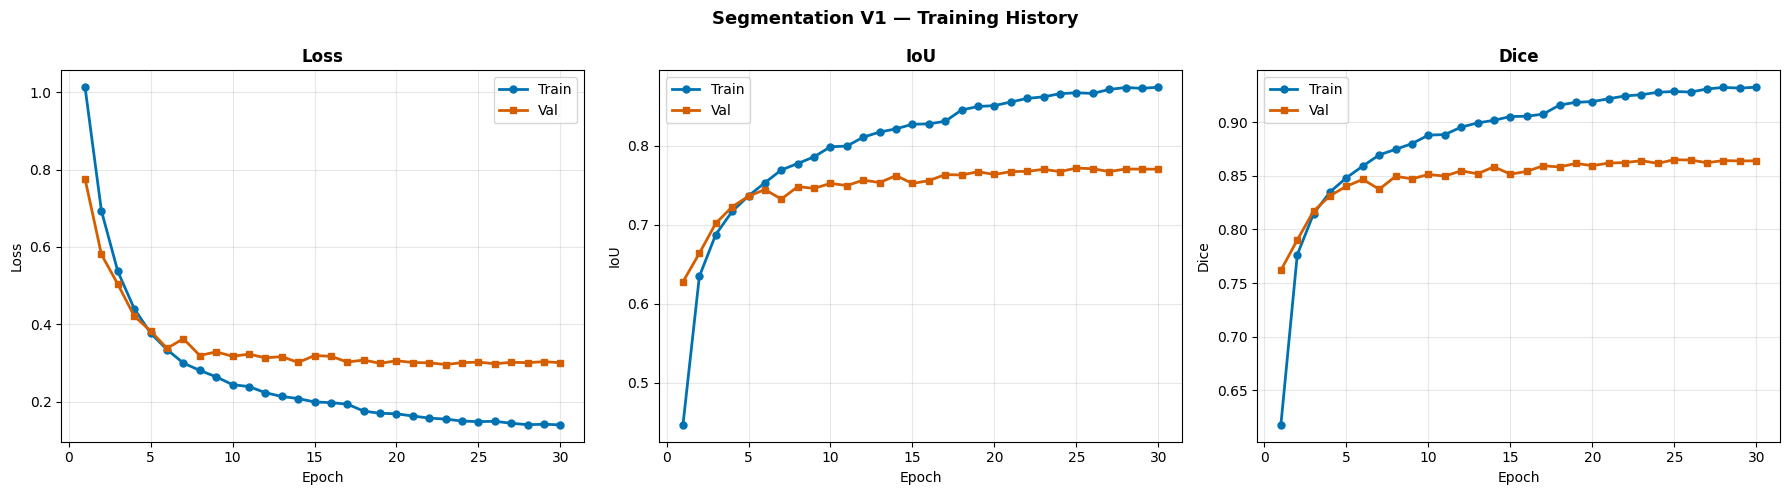

Saved → visualizations/segmentation_v1/training_curves.png


In [8]:
epoch_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Segmentation V1 — Training History", fontsize=13, fontweight="bold")

axes[0].plot(epoch_range, history['train_loss'], "o-", color="#0072B2", linewidth=2, markersize=5, label="Train")
axes[0].plot(epoch_range, history['val_loss'],   "s-", color="#D55E00", linewidth=2, markersize=5, label="Val")
axes[0].set_title("Loss", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epoch_range, history['train_iou'], "o-", color="#0072B2", linewidth=2, markersize=5, label="Train")
axes[1].plot(epoch_range, history['val_iou'],   "s-", color="#D55E00", linewidth=2, markersize=5, label="Val")
axes[1].set_title("IoU", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("IoU")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epoch_range, history['train_dice'], "o-", color="#0072B2", linewidth=2, markersize=5, label="Train")
axes[2].plot(epoch_range, history['val_dice'],   "s-", color="#D55E00", linewidth=2, markersize=5, label="Val")
axes[2].set_title("Dice", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Dice")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {VIZ_DIR}/training_curves.png")

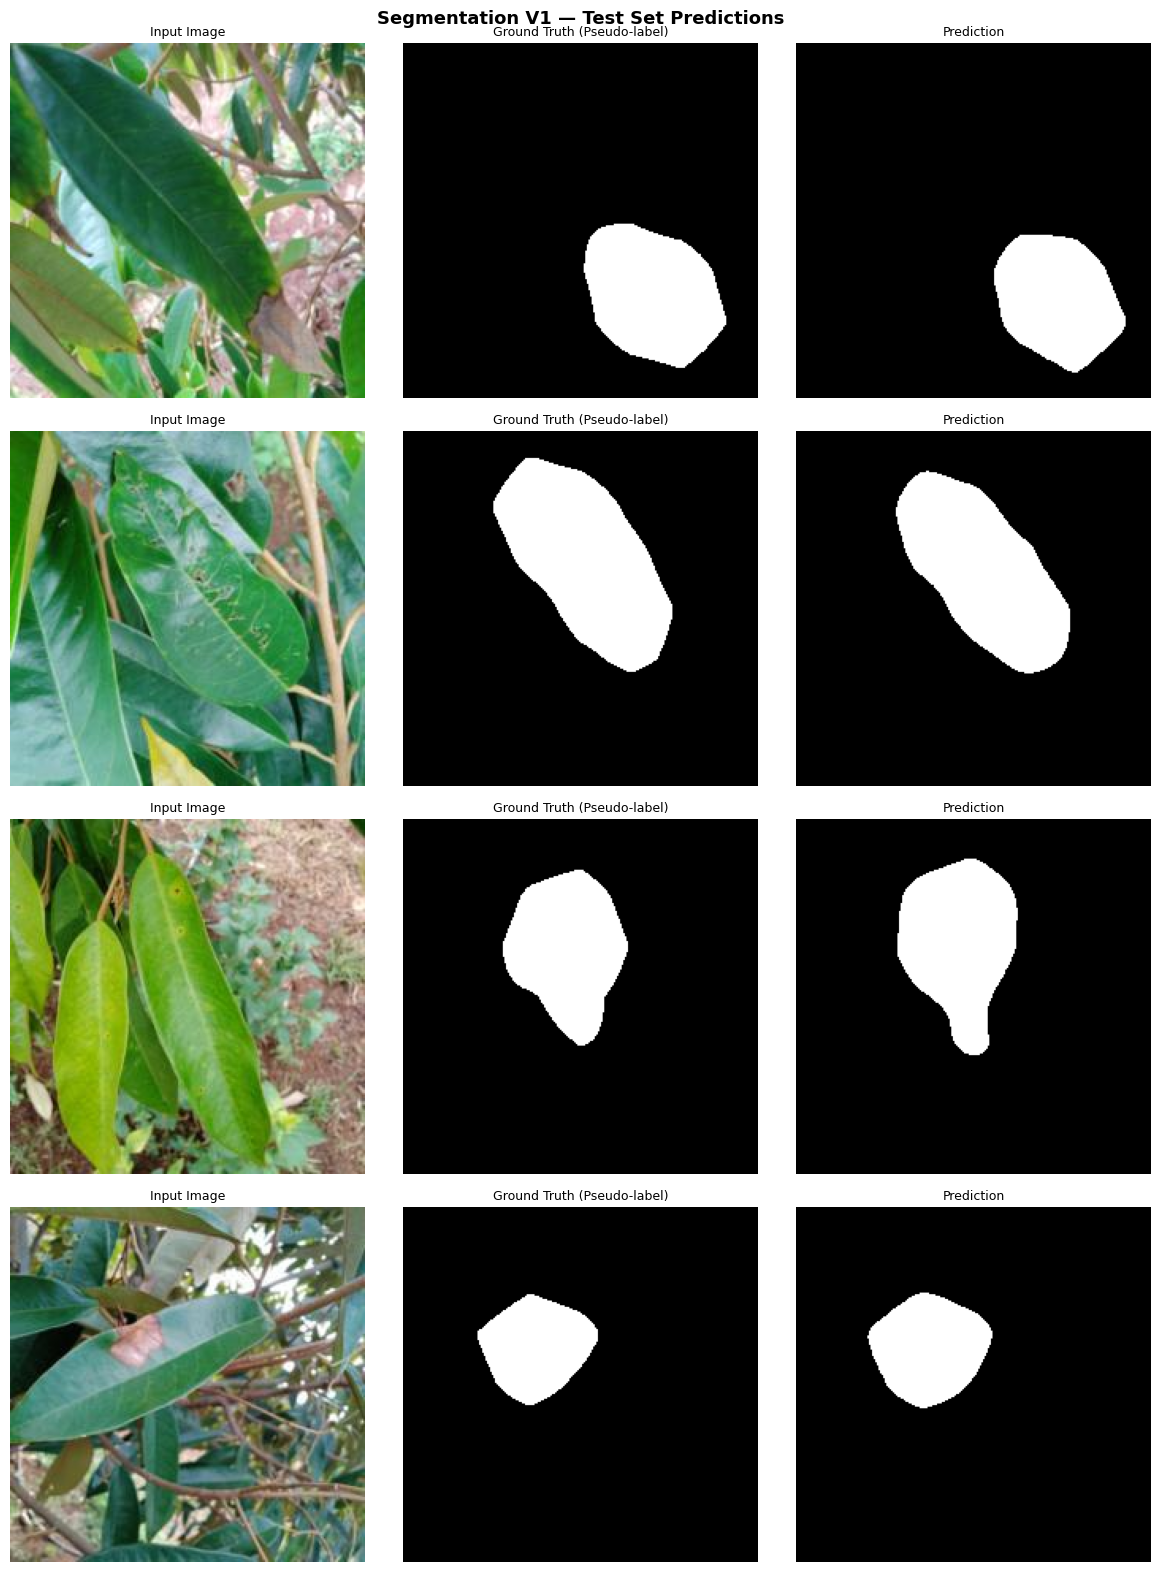

Saved → visualizations/segmentation_v1/test_predictions.png


In [9]:
model.eval()
sample_batch = next(iter(test_loader))
imgs = sample_batch['image'].to(device)
masks_gt = sample_batch['label']

with torch.no_grad():
    outputs = model(imgs)
    preds = (torch.sigmoid(outputs) > 0.5).float()

n_show = min(4, len(imgs))
fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
fig.suptitle("Segmentation V1 — Test Set Predictions", fontsize=13, fontweight="bold")
if n_show == 1:
    axes = axes.reshape(1, -1)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i in range(n_show):
    img_denorm = (imgs[i].cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    gt_mask    = masks_gt[i, 0].numpy()
    pred_mask  = preds[i, 0].cpu().numpy()

    axes[i, 0].imshow(img_denorm)
    axes[i, 0].set_title("Input Image", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(gt_mask, cmap="gray")
    axes[i, 1].set_title("Ground Truth (Pseudo-label)", fontsize=9)
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred_mask, cmap="gray")
    axes[i, 2].set_title("Prediction", fontsize=9)
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "test_predictions.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {VIZ_DIR}/test_predictions.png")

---

## Kết luận — Segmentation V1 (EfficientNet-UNet)

**Tóm tắt kết quả:**

- Model hội tụ tốt trong 30 epochs — best checkpoint tại epoch 23 (val_loss=0.2959)
- Test IoU **0.7671**, Dice **0.8623** — số tốt so với kỳ vọng cho weakly-supervised baseline
- Recall > Precision (0.8877 vs 0.8562) → model có xu hướng over-segment, phù hợp với ứng dụng phát hiện bệnh (bỏ sót nguy hiểm hơn là đánh dư)

**Tại sao số lại cao?** — Cần hiểu đúng ngữ cảnh:

- Ground truth ở đây là **pseudo-label từ GradCAM**, không phải annotation thật
- Pseudo-label v1 có dạng blob lớn, mịn, pattern đơn giản → EfficientNet-B0 pretrained dễ học lại
- Nói đúng hơn: model đang học cách **tái tạo GradCAM activation pattern**, chưa phải học **boundary của lesion thật**
- Đây là giới hạn của toàn bộ pipeline weakly-supervised — không tránh được ở V1

**Hạn chế kỹ thuật:**

- Augmentation quá đơn giản (chỉ flip) — dataset nhỏ 3K ảnh cần augmentation đa dạng hơn
- BCE+Dice không xử lý tốt class imbalance (background >> lesion pixels)
- Pseudo-label v1 có coverage rộng (12–26%) và biên coarse từ 7×7 GradCAM upsampled
- Augmentation bug nhỏ: `train_seg.dataset.augment = True` vô tình bật augment trên val/test (chỉ flip nên ảnh hưởng nhỏ)

**Vai trò của V1:**

V1 là **baseline tham chiếu**, không phải kết quả cuối. Mọi cải tiến ở V2 (NB08) và V3 (NB09) sẽ được so sánh ngược lại con số này — IoU 0.7671 và Dice 0.8623 là điểm khởi đầu cần vượt qua.